In [1]:
import sys
sys.path.append('../')

from BPMQ import *
import numpy as np

import torch
torch.autograd.set_detect_anomaly(True)

In [2]:
machineIO = construct_machineIO()
machineIO._test = True
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 1
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.2

E_MeVu = 130
Mass_number = 18
Charge_number = 8

# preprare BPMQ scan

In [3]:
# Example usage (assuming you have the helper functions defined as before):
filename = "lattice.txt"  # Replace with your lattice file
from_elem = "BDS_BTS:QV_D5501"
to_elem = "BDS_BTS:PM_D5567"
lattice_dicts = fmlat.combine_lattice_elements_quads_only(filename, from_element=from_elem, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])
#, line_name = "cell")
# qnames = ["BDS_BTS:PSQ_D5501", "BDS_BTS:PSQ_D5509", "BDS_BTS:PSQ_D5552", "BDS_BTS:PSQ_D5559"]
qnames = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
qnames = qnames[-4:]
qnames

['BDS_BTS:PSQ_D5501',
 'BDS_BTS:PSQ_D5509',
 'BDS_BTS:PSQ_D5552',
 'BDS_BTS:PSQ_D5559']

In [4]:
args = (E_MeVu, Mass_number, Charge_number)
kwargs = {
    "quads_to_scan": qnames,
    "quads_max_curr": [180, 180, 180, 180],
    "quads_min_curr": [ 10,  10,  10,  10],
    "BPM_names": ["BDS_BTS:BPM_D5513", "BDS_BTS:BPM_D5565"],
    "lattice_dicts" : lattice_dicts,
    "xnemit_target": None,
    "ynemit_target": None,
    "ISAAC_preset_keywords":["BDS"],
    "bootstrap":False,
    "machineIO": None,
    "plot_history":True, 
    "plot_ellipse":True,
    "fit_err":False
}

# Run for various virtual Qerrs

In [5]:
def measure_rms(bpmQscan):
    env_model = bpmQscan.quads_evaluator.env_model
    xcov, ycov = env_model.simulate_beam_covars(env_model.xcovs,env_model.ycovs,i_monitors=env_model.i_pms)
    xrms, yrms = xcov[0,0,0,0]**0.5*1e3, ycov[0,0,0,0]**0.5*1e3
    lB2 = []
    for quad in env_model.quads_to_scan:
        lB2.append(quad.properties['B2'])
    return lB2, xrms, yrms

In [6]:
# BPMQ_i_monitors = bpmQscan.i_bpms
# BPMQ_llB2 = bpmQscan.train_llB2
# BPMQ_targets = bpmQscan.train_llBPMQ
# BPMQ_tolerances = bpmQscan.train_llBPMQtol
# BPMQ_model_err = bpmQscan.train_llBPMQmodelerr
# PM_i_monitors=bpmQscan.i_pms
# PM_llB2=bpmQscan.train_llB2rms
# PM_xrms_targets=bpmQscan.train_llxrms
# PM_yrms_targets=bpmQscan.train_llyrms
# PM_xrms_tolerances=bpmQscan.train_llxrmstol
# PM_yrms_tolerances=bpmQscan.train_llyrmstol
# fit_err = False
# i_extra_aper = None
# xnemit_target=None
# ynemit_target=None
# batch_size= 8
# max_iter= 150
# bootstrap = False
# sample_model_err = False

In [7]:
# _n_batch_padding_factor = 4

# print(" ======== cs_reconstruct ========")
# assert set(BPMQ_i_monitors) <= set(bpmQscan.model.i_bpms)
# bpmQscan.model.BPMQ_llB2 = BPMQ_llB2
# bpmQscan.model.PM_llB2 = PM_llB2

# if BPMQ_tolerances is None:
#     BPMQ_tolerances = 0.5*torch.ones(len(BPMQ_i_monitors)) # combined loss is weighed assuming BPMQ error <~ 0.5 mm^2 
# else:
#     if torch.any(BPMQ_tolerances <= 1e-6):
#         raise ValueError("BPMQ_tolerances must not be negative or smaller than machine precision")
#     BPMQ_tolerances = BPMQ_tolerances / BPMQ_tolerances.mean() *0.5  # combined loss is weighed assumingBPMQ error <~ 0.5 mm^2

# if BPMQ_tolerances.ndim == 1:
#     BPMQ_tolerances = BPMQ_tolerances.view(1,-1,1)
# else:
#     BPMQ_tolerances = BPMQ_tolerances[:,:,None]

# if sample_model_err and BPMQ_model_err is not None:
#     BPMQ_targets_samples = BPMQ_targets.unsqueeze(-1).expand(-1, -1, batch_size * _n_batch_padding_factor)
#     BPMQ_targets_samples = BPMQ_targets_samples + BPMQ_model_err[:, :, None] * torch.randn_like(BPMQ_targets_samples)
# else:
#     BPMQ_targets_samples = BPMQ_targets[:, :, None]

# if PM_xrms_targets is not None:
#     assert set(PM_i_monitors) <= set(bpmQscan.model.i_pms)
#     if PM_xrms_tolerances is None:
#         PM_xrms_tolerances = torch.ones(len(PM_i_monitors))
#     else:
#         if torch.any(PM_xrms_tolerances <= 1e-6):
#             raise ValueError("PM_rms_tolerances must not be negative or smaller than machine precision")
#     PM_xrms_tolerances = PM_xrms_tolerances / PM_xrms_tolerances.mean()
#     if PM_yrms_tolerances is None:
#         PM_yrms_tolerances = torch.ones(len(PM_i_monitors))
#     else:
#         if torch.any(PM_yrms_tolerances <= 1e-6):
#             raise ValueError("PM_rms_tolerances must not be negative or smaller than machine precision")
#     PM_yrms_tolerances = PM_yrms_tolerances / PM_yrms_tolerances.mean()
#     if PM_xrms_tolerances.ndim == 1:
#         PM_xrms_tolerances = PM_xrms_tolerances.view(1,-1,1)
#     else:
#         PM_xrms_tolerances = PM_xrms_tolerances[:,:,None]
#     if PM_yrms_tolerances.ndim == 1:
#         PM_yrms_tolerances = PM_yrms_tolerances.view(1,-1,1)
#     else:
#         PM_yrms_tolerances = PM_yrms_tolerances[:,:,None]

#     PM_xrms_targets = PM_xrms_targets[:, :, None]
#     PM_yrms_targets = PM_yrms_targets[:, :, None]

# args = (BPMQ_i_monitors, BPMQ_llB2, BPMQ_targets_samples, BPMQ_tolerances)


# kwargs = {
#     'fit_err': fit_err,
#     'iPM': PM_i_monitors,
#     'PM_llB2': PM_llB2,
#     'PM_xrms_targets': PM_xrms_targets,
#     'PM_yrms_targets': PM_yrms_targets,
#     'PM_xrms_tolerances': PM_xrms_tolerances,
#     'PM_yrms_tolerances': PM_yrms_tolerances,
#     'xnemit_target': xnemit_target,
#     'ynemit_target': ynemit_target,
# }
# loss_weights = {'fitloss_bpmQ':1.0, 
#                 'fitloss_PM':5.0, 
#                 'regloss_beamloss':1.0, 
#                 'regloss_PM_err':5.0, 
#                 'regloss_bpmQ_err':1.0, 
#                 'regloss_emitprior':1.0
#                 }


# loss_func = bpmQscan.model._get_cs_reconst_loss_ftn(*args,**kwargs,
#     compute_beam_loss = True,
#     i_extra_aper = i_extra_aper)
# loss_func_wo_beamloss = bpmQscan.model._get_cs_reconst_loss_ftn(*args,**kwargs,
#     compute_beam_loss = False)

# n_param = 6
# n_bpmQ_err = 0
# n_pm_err = 0
# if fit_err:
#     n_bpmQ_err = BPMQ_targets.shape[0] * BPMQ_targets.shape[1]
#     n_param += n_bpmQ_err
#     if PM_llB2 is not None:
#         n_pm_err = PM_xrms_targets.shape[0] * PM_xrms_targets.shape[1]
#         n_param += n_pm_err*2
# x0 = torch.randn(batch_size*_n_batch_padding_factor, n_param, dtype=bpmQscan.model.dtype, requires_grad=True)

# with torch.profiler.profile(
#     activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA],
#     record_shapes=True,
#     profile_memory=True,
#     with_stack=True
# ) as prof:
#     output = loss_func(x0)

# # Print profiling results
# print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=10))
# # Optionally export to a file for visualization in Chrome tracing
# prof.export_chrome_trace("profile_trace.json")

after init, number of training data is 4
 ======== cs_reconstruct ========


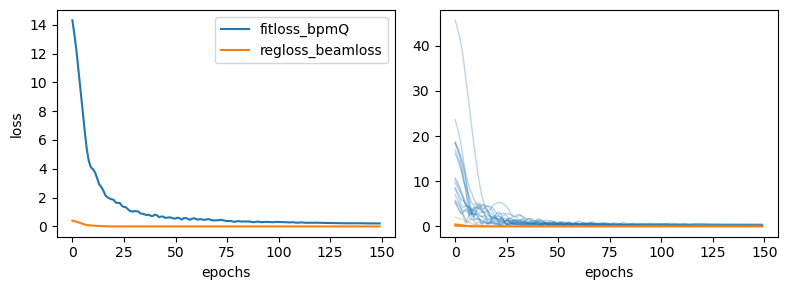

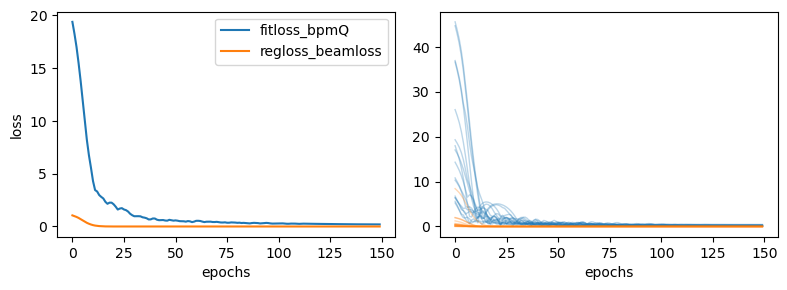

445.6355745719993


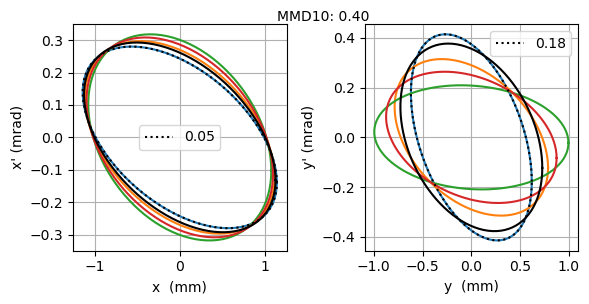

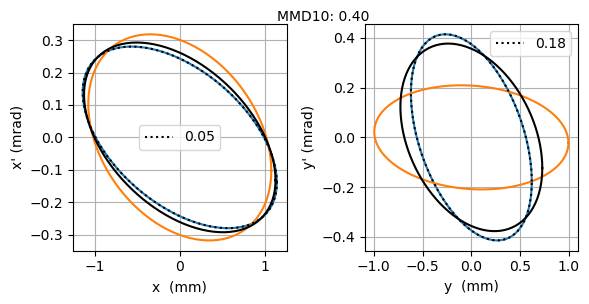

In [8]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs, 
                    virtual_beamQerr=0.0)
bpmQscan.initialize()
print(time.monotonic()-start_time)

after init, number of training data is 4
 ======== cs_reconstruct ========


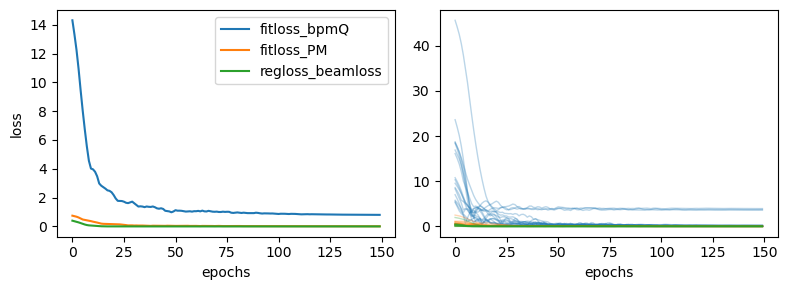

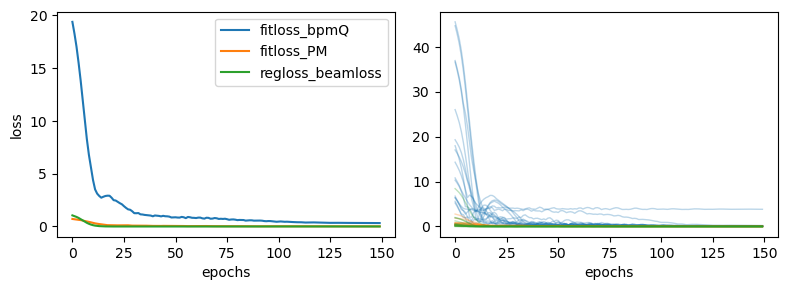

1557.5559324639999


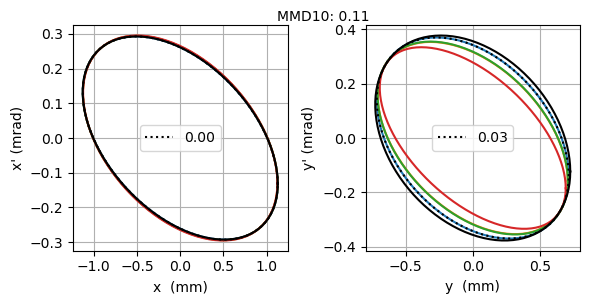

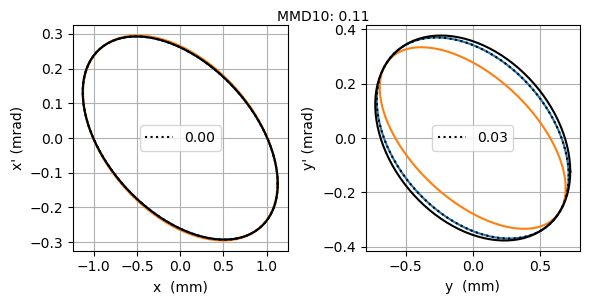

In [9]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs, 
                    virtual_beamQerr=0.0)
lB2, xrms, yrms = measure_rms(bpmQscan)
bpmQscan.concat_PM_train_data(lB2=lB2, lxrms=[xrms],lyrms=[yrms],lxrmstol=[0.1],lyrmstol=[0.1])
bpmQscan.initialize()
print(time.monotonic()-start_time)

In [ ]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs, 
                    virtual_beamQerr=0.0)
lB2, xrms, yrms = measure_rms(bpmQscan)
bpmQscan.concat_PM_train_data(lB2=lB2, lxrms=[xrms],lyrms=[yrms],lxrmstol=[0.1],lyrmstol=[0.1])
bpmQscan.initialize()

n = len(bpmQscan.train_llB2)
while len(bpmQscan.train_llB2)==n:
    bpmQscan.step()
    
lB2, xrms, yrms = measure_rms(bpmQscan)

n = len(bpmQscan.train_llB2)
while len(bpmQscan.train_llB2)==n:
    bpmQscan.step()
    
lB2, xrms, yrms = measure_rms(bpmQscan)
    
while len(bpmQscan.train_llB2)<10:
    bpmQscan.step()
    
elapsed_time_minutes = (time.monotonic() - start_time) / 60
print(f"Elapsed time: {elapsed_time_minutes:.2f} minutes, nBPMQ data:{len(bpmQscan.train_llB2)}")
l_xcovs, l_ycovs = fmlat.update_lattice_file_from_bpmQscan(filename,bpmQscan)

In [ ]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs, 
                    virtual_beamQerr=0.8)
lB2, xrms, yrms = measure_rms(bpmQscan)
bpmQscan.concat_PM_train_data(lB2=lB2, lxrms=[xrms],lyrms=[yrms],lxrmstol=[0.1],lyrmstol=[0.1])
bpmQscan.initialize()

n = len(bpmQscan.train_llB2)
while len(bpmQscan.train_llB2)==n:
    bpmQscan.step()
    
lB2, xrms, yrms = measure_rms(bpmQscan)

n = len(bpmQscan.train_llB2)
while len(bpmQscan.train_llB2)==n:
    bpmQscan.step()
    
lB2, xrms, yrms = measure_rms(bpmQscan)
    
while len(bpmQscan.train_llB2)<10:
    bpmQscan.step()
    
elapsed_time_minutes = (time.monotonic() - start_time) / 60
print(f"Elapsed time: {elapsed_time_minutes:.2f} minutes, nBPMQ data:{len(bpmQscan.train_llB2)}")
l_xcovs, l_ycovs = fmlat.update_lattice_file_from_bpmQscan(filename,bpmQscan)